# Atividade 1.3 - Erros

Aluno: Vinicius Batista Duarte

Exercício 1.1 O método “divisão e média”, um método antigo para estimação de raiz quadrada de um número positivo a, pode ser formulado como  xi+1 = (xi + (a/xi))/ 2 .  Calcule o erro relativo da aproximação para as 10 primeiras iterações.

In [83]:
a = 25 # Valor que desejo descobrir a raiz quadrada
x = 8  # Raiz estipulada

In [65]:
for xi in range(1,11):
    x = (x + (a/x))/ 2
    print(x)

5.5625
5.028441011235955
5.0000804316008
5.000000000646914
5.0
5.0
5.0
5.0
5.0
5.0


Exercício 1.2 Para computadores, o épsilon da máquina, ε, pode ser definido como o menor número que, adicionado a um, retorna um número maior que um, como definimos anteriormente. Usando o algoritmo abaixo, implemente um programa que calcula o épsilon da sua máquina. Compare com os resultados obtidos via numpy.

- Passo 1: Defina e = 1
- Passo 2: Se 1 + e for menor ou igual a 1, vá para o Passo 5; caso contrário, vá ao Passo 3
- Passo 3: e = e/2
- Passo 4: Retorne ao Passo 2
- Passo 5: e = 2 x e

In [66]:
e = 1.0

while True:
    if (1 + e) > 1:
        e = e / 2
    else:
        e = e * 2
        break

In [67]:
import numpy as np

In [68]:
print(f"Épsilon calculado : {e}")
print(f"Épsilon do NumPy  : {np.finfo(np.float64).eps}")

if e == np.finfo(np.float64).eps:
    print("Os valores são iguais.")
else:
    print("Os valores são diferentes.")

Épsilon calculado : 2.220446049250313e-16
Épsilon do NumPy  : 2.220446049250313e-16
Os valores são iguais.


Exercício 1.3 Considere o seguinte processo iterativo:

x^(1) = 1/3

x^(n+1) = 4x^(1) − 1, n = 1, 2, . . .

Observe que x(1) = 1/3, x^(2) = 4*1/3 − 1 = 1/3, x^(3) = 4*1/3 − 1 = 1/3, e por aí vai, ou seja, temos uma sequência constante igual a 1/3.

Implemente essa série iterativa, verificando se a convergência de fato ocorre e justifique
o resultado obtido.

In [69]:
x = 1/3
x_exato = 1/3

iteracoes = []
erros = []

print(f"{'Iter':>4} {'x':>22} {'Erro Absoluto':>22}")

for i in range(10):
    x = 4*x - 1
    erro = abs(x - x_exato)
    iteracoes.append(i + 1)
    erros.append(erro)
    print(f"{i+1:4d} {x:22.18f} {erro:22.18f}")

Iter                      x          Erro Absoluto
   1   0.333333333333333259   0.000000000000000056
   2   0.333333333333333037   0.000000000000000278
   3   0.333333333333332149   0.000000000000001166
   4   0.333333333333328596   0.000000000000004718
   5   0.333333333333314386   0.000000000000018929
   6   0.333333333333257542   0.000000000000075773
   7   0.333333333333030168   0.000000000000303146
   8   0.333333333332120674   0.000000000001212641
   9   0.333333333328482695   0.000000000004850620
  10   0.333333333313930780   0.000000000019402535


In [70]:
import matplotlib.pyplot as plt

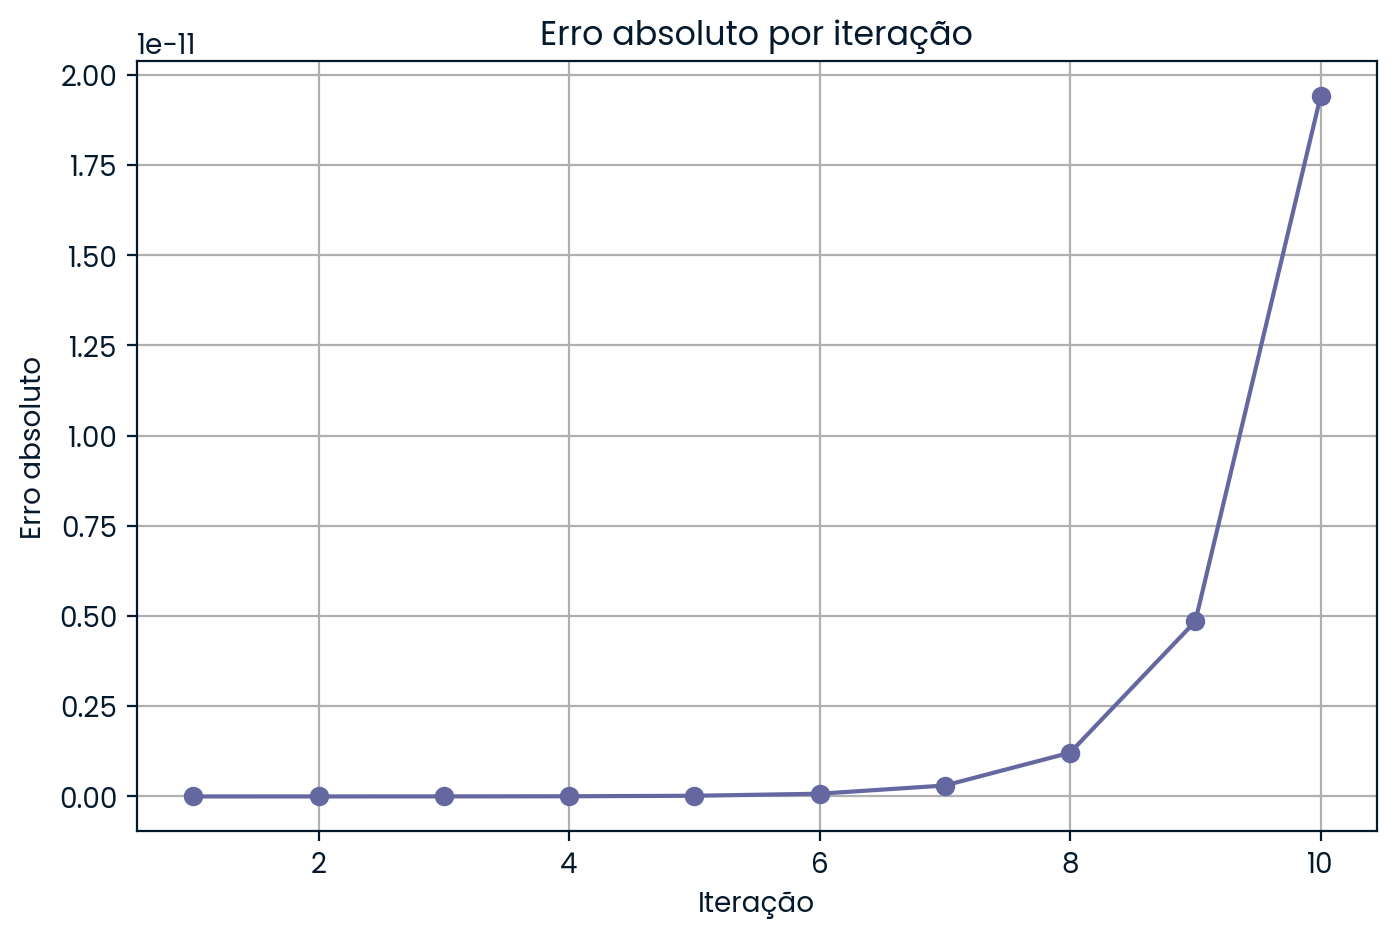

In [71]:
plt.figure(figsize=(8, 5))
plt.plot(iteracoes, erros, marker='o')
plt.title("Erro absoluto por iteração")
plt.xlabel("Iteração")
plt.ylabel("Erro absoluto")
plt.grid(True)

plt.show()

In [72]:
# A cada iteração o valor de x deveria permanecer o mesmo, pois é isso que o algoritmo propôe.  Entretanto, isso não ocorre na prática. Cada iteração amplifica o erro de arredondamento em um fator de 4. Isso aconte pois o valor de 1/3 não possui uma representação finita em binário, gerando um arredondamento. 

Exercício 1.4 Considere as expressões: exp(1/μ) / (1 + exp(1/μ)) e 1 /  (exp(−1/μ) + 1 com μ > 0. Verifique que elas são idênticas como funções reais. Teste no computador cada
uma delas para μ = 0, 1, μ = 0, 01, μ = 0, 001 ou menor e responda: Qual dessas expressões é
mais adequada quando μ é um número pequeno? Por quê?

In [73]:
list_u = [0.1, 0.01, 0.001, 0.0001]
list_x = []

for u in list_u:
    list_x.append(1 / u)

print(list_x)

[10.0, 100.0, 1000.0, 10000.0]


In [74]:
print("a - x")

for x in list_x:
    a = np.exp(x) / (1 + np.exp(x))
    print(f"{a} - {x} - {np.exp(x)}")


a - x
0.9999546021312976 - 10.0 - 22026.465794806718
1.0 - 100.0 - 2.6881171418161356e+43
nan - 1000.0 - inf
nan - 10000.0 - inf


In [75]:
print("a - x")

for x in list_x:
    a = 1 / (np.exp(-x) + 1)
    print(f"{a} - {x} - {np.exp(-x)}")


a - x
0.9999546021312976 - 10.0 - 4.5399929762484854e-05
1.0 - 100.0 - 3.720075976020836e-44
1.0 - 1000.0 - 0.0
1.0 - 10000.0 - 0.0


In [76]:
# A segunda expressão é mais adequada, pois na primeira o valor de exp(-x) se torna muito alto e a partir de certo momento passa a ser tratado como infinito. Resultando em inf/inf = nan. 

Exercício 1.5 Observe a seguinte identidade

f(x) = ((1 + x) − 1 )/ x

Não é muito difícil verificar, analiticamente, que, para qualquer valor de x, sempre teremos f(x) = 1. Faça um programa que calcule o valor da expressão para x = 10^−12, x = 10^−15 e x = 10^−17. Compare os resultados com o resultado analítico e explique-os.

In [77]:
list_x1 = [1e-12, 1e-15, 1e-17]

for x1 in list_x1:
    a = ((1+x1) - 1) / x1
    print(f"{a}")

1.000088900582341
1.1102230246251565
0.0


In [78]:
# O valor de x = 10^-17 é menor que o éplison, então ao fazer 1 + x o resulta é 1, resultando em 0 / x = 0. 

Exercício 1.6 Existem diferentes métodos para calcular aproximadamente o valor de π computacionalmente. Vários desses métodos usam a aproximação por séries de Taylor para o arcotangente. São alguns desses métodos:

a) Fórmula de Machin
b) Fórmula de Hutton
c) Fórmula de Clausen
d) Fórmula de Dase

Gere gráficos que comparem a evolução do erro em função do número de termos considerados, para os vinte primeiros termos de cada método descrito acima e comente os resultados obtidos.

In [79]:
def arctan_taylor(x, n):
    soma = 0.0
    for k in range(n):
        soma += (-1)**k * x**(2*k+1) / (2*k+1)
    return soma


def machin(n):
    return 16*arctan_taylor(1/5, n) - 4*arctan_taylor(1/239, n)


def hutton(n):
    return 4*(arctan_taylor(1/2, n)
              + arctan_taylor(1/3, n))


def clausen(n):
    return 8*arctan_taylor(1/3, n) + 4*arctan_taylor(1/7, n)


def dase(n):
    return 4*(arctan_taylor(1/2, n)
              + arctan_taylor(1/5, n)
              + arctan_taylor(1/8, n))

In [80]:
pi_real = np.pi

termos = range(1, 21)

erro_machin = []
erro_hutton = []
erro_clausen = []
erro_dase = []

for n in termos:
    erro_machin.append(abs(pi_real - machin(n)))
    erro_hutton.append(abs(pi_real - hutton(n)))
    erro_clausen.append(abs(pi_real - clausen(n)))
    erro_dase.append(abs(pi_real - dase(n)))


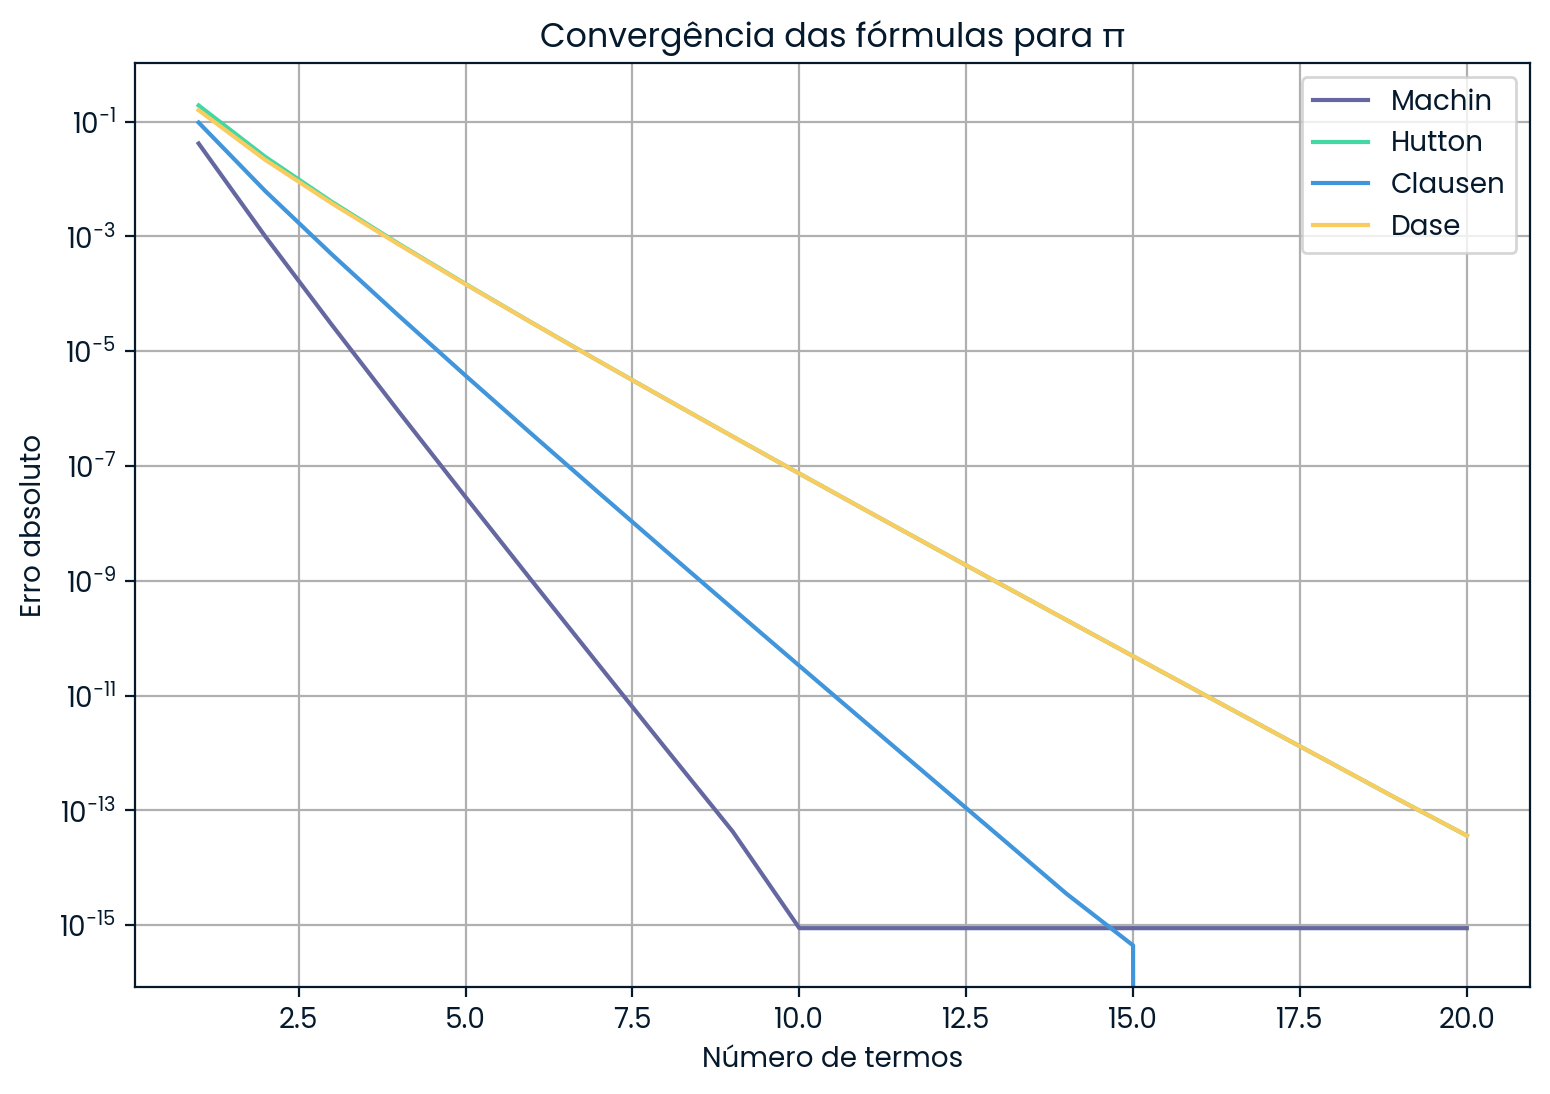

In [81]:
plt.figure(figsize=(9,6))

plt.semilogy(termos, erro_machin, '-', label='Machin')
plt.semilogy(termos, erro_hutton, '-', label='Hutton')
plt.semilogy(termos, erro_clausen, '-', label='Clausen')
plt.semilogy(termos, erro_dase, '-', label='Dase')

plt.xlabel("Número de termos")
plt.ylabel("Erro absoluto")
plt.title("Convergência das fórmulas para π")
plt.grid(True, which="both")
plt.legend()

plt.show()

In [82]:
# O gráfico mostra que todas as fórmulas convergem para o valor de π, porém com velocidades diferentes. A fórmula de Machin apresentou a convergência mais rápida, atingindo um erro muito pequeno com poucos termos. A fórmula de Clausen também convergiu rapidamente, mas foi um pouco mais lenta que Machin. Já as fórmulas de Hutton e Dase apresentaram uma redução mais lenta do erro, necessitando de um maior número de termos para obter a mesma precisão. Observa-se ainda que, após certo número de termos, o erro deixa de diminuir e se estabiliza em torno de 10^−15, devido ao limite de precisão do tipo float64 utilizado pelo computador. Dessa forma, conclui-se que a fórmula de Machin é a mais eficiente entre as analisadas para aproximar o valor de π.